<a href="https://colab.research.google.com/github/ma7moudabdelza7er/Apply-to-KMeans/blob/main/Copy_of_Getting_started_with_google_colab_ai.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans

In [2]:
df = pd.read_csv('/content/Mall_Customers.csv')
df

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40
...,...,...,...,...,...
195,196,Female,35,120,79
196,197,Female,45,126,28
197,198,Male,32,126,74
198,199,Male,32,137,18


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


In [3]:
df.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


In [4]:
df.isnull().sum()

,0
CustomerID,0
Gender,0
Age,0
Annual Income (k$),0
Spending Score (1-100),0


In [5]:
df.columns = ['CustomerID','Gender','Age','AnnalIncome','SpendingScore']
df

,CustomerID,Gender,Age,AnnalIncome,SpendingScore
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40
...,...,...,...,...,...
195,196,Female,35,120,79
196,197,Female,45,126,28
197,198,Male,32,126,74
198,199,Male,32,137,18


In [6]:
corr = df[['AnnalIncome','SpendingScore']].corr()
corr

,AnnalIncome,SpendingScore
AnnalIncome,1.000000,0.009903
SpendingScore,0.009903,1.000000


<Axes: >

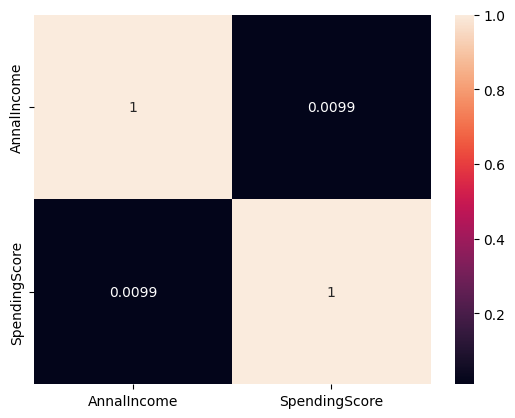

In [7]:
sns.heatmap(corr,annot=True)

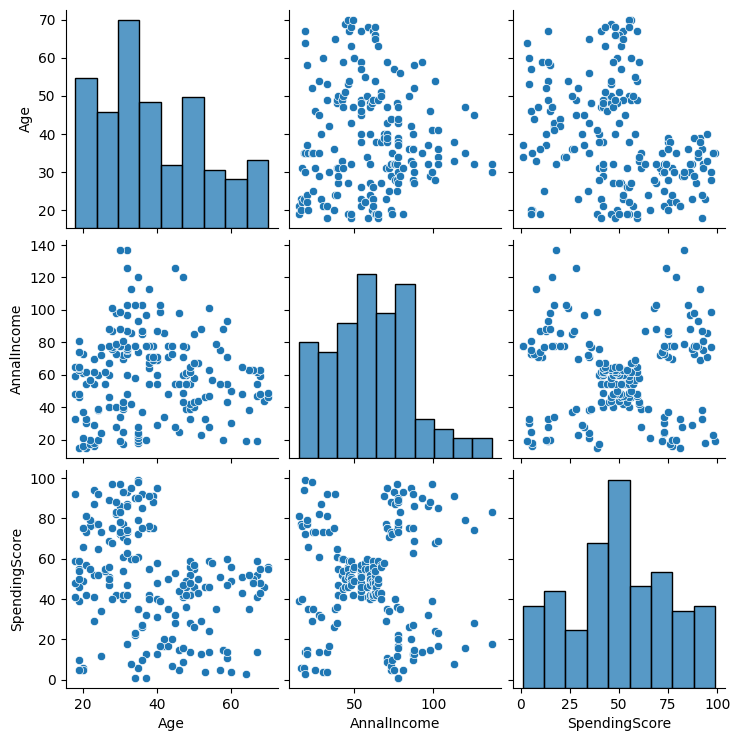

In [ ]:
sns.pairplot(df[['Age','AnnalIncome','SpendingScore']])

Text(0, 0.5, 'SpendingScore')

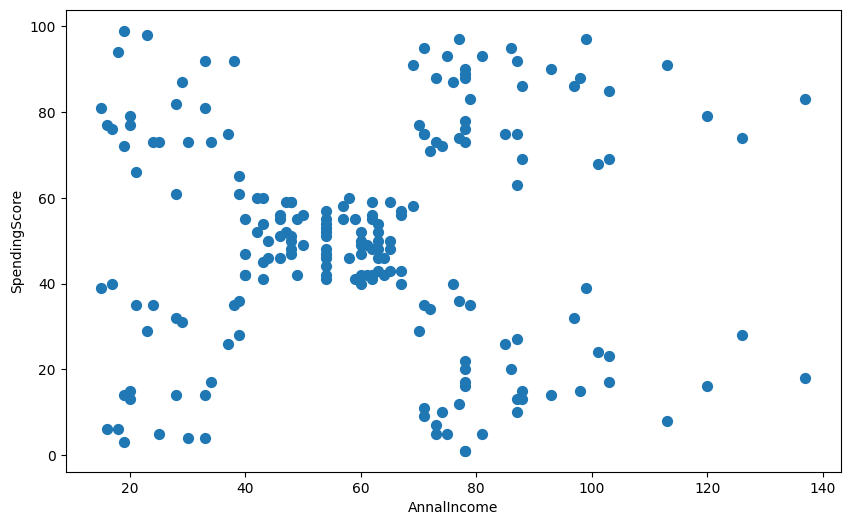

In [8]:
plt.figure(figsize=(10,6))
plt.scatter(df['AnnalIncome'],df['SpendingScore'],s=50)
plt.xlabel('AnnalIncome')
plt.ylabel('SpendingScore')

In [9]:
x = df[['AnnalIncome','SpendingScore']]
Wcss = []
for i in range(1,11):
  kmeans = KMeans(n_clusters = i,init ='k-means++',max_iter=300,n_init=10,random_state=0)
  kmeans.fit(x)
  Wcss.append(kmeans.inertia_)

Text(0, 0.5, 'Wcss')

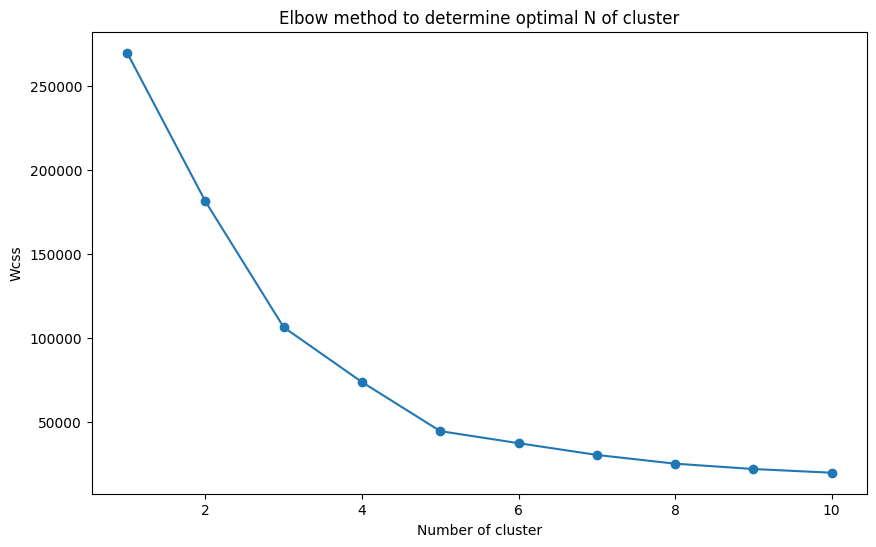

In [10]:
plt.figure(figsize=(10,6))
plt.plot(range(1,11),Wcss,marker='o')
plt.title('Elbow method to determine optimal N of cluster')
plt.xlabel('Number of cluster')
plt.ylabel('Wcss')

In [11]:
kmeans = KMeans(n_clusters = 5,init ='k-means++',max_iter=300,n_init=10,random_state=0)
y_kmeans = kmeans.fit_predict(x)

In [12]:
df['Cluster'] = y_kmeans
df.head()

,CustomerID,Gender,Age,AnnalIncome,SpendingScore,Cluster
0,1,Male,19,15,39,3
1,2,Male,21,15,81,4
2,3,Female,20,16,6,3
3,4,Female,23,16,77,4
4,5,Female,31,17,40,3


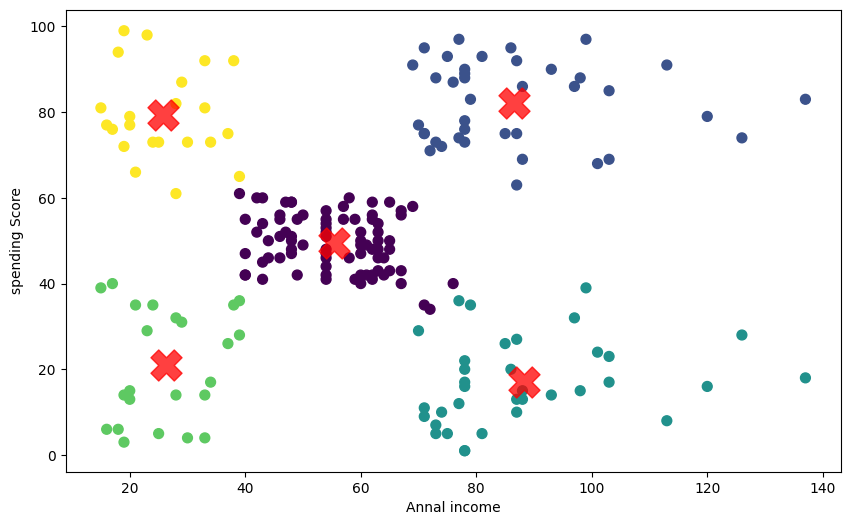

In [20]:
plt.figure(figsize=(10,6))
plt.scatter(x.iloc[:,0],x.iloc[:,1],c=y_kmeans,s=50,cmap='viridis')
centers = kmeans.cluster_centers_
plt.scatter(centers[:,0],centers[:,1],c='red',s=500,alpha=0.75,marker="X")
plt.xlabel('Annal income')
plt.ylabel('spending Score')
plt.show()

In [ ]:
x.iloc[:,0]
x.iloc[:,1]

,SpendingScore
0,39
1,81
2,6
3,77
4,40
...,...
195,79
196,28
197,74
198,18


In [19]:
centers = kmeans.cluster_centers_

np.float64(55.29629629629632)

Text(0, 0.5, 'SpendingScore')

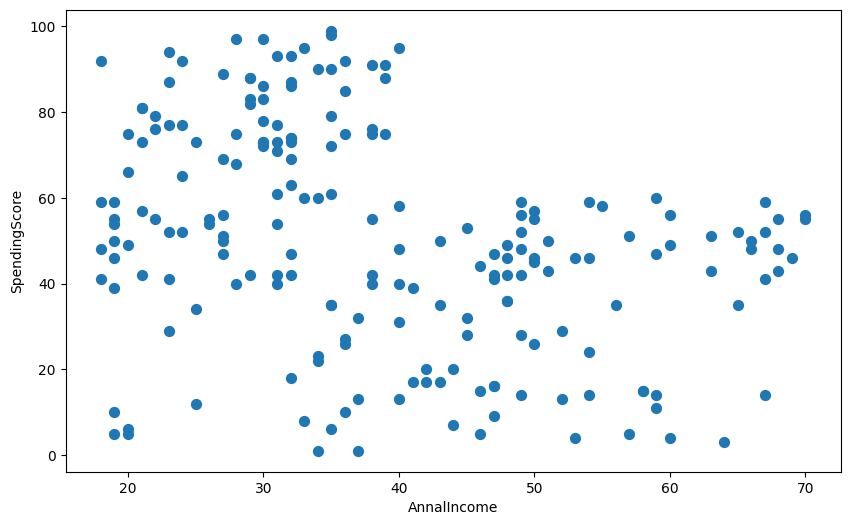

In [21]:
plt.figure(figsize=(10,6))
plt.scatter(df['Age'],df['SpendingScore'],s=50)
plt.xlabel('AnnalIncome')
plt.ylabel('SpendingScore')

In [22]:
x = df[['Age','SpendingScore']]
Wcss = []
for i in range(1,11):
  kmeans = KMeans(n_clusters = i,init ='k-means++',max_iter=300,n_init=10,random_state=0)
  kmeans.fit(x)
  Wcss.append(kmeans.inertia_)

Text(0, 0.5, 'Wcss')

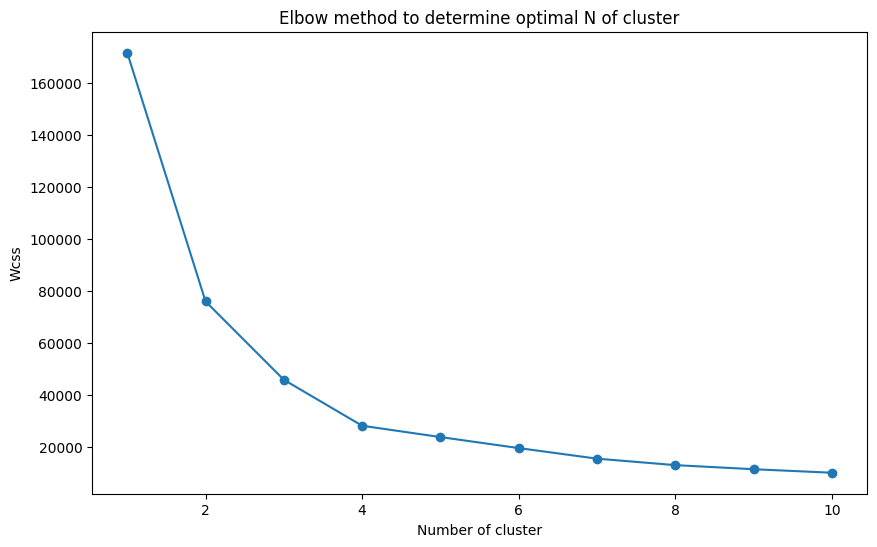

In [24]:
plt.figure(figsize=(10,6))
plt.plot(range(1,11),Wcss,marker='o')
plt.title('Elbow method to determine optimal N of cluster')
plt.xlabel('Number of cluster')
plt.ylabel('Wcss')

In [ ]:
kmeans = KMeans(n_clusters = 4,init ='k-means++',max_iter=300,n_init=10,random_state=0)
y_kmeans = kmeans.fit_predict(x)
df['ClusterAge'] = y_kmeans
df.head()

,CustomerID,Gender,Age,AnnalIncome,SpendingScore,Cluster,ClusterAge
0,1,Male,19,15,39,3,3
1,2,Male,21,15,81,4,1
2,3,Female,20,16,6,3,2
3,4,Female,23,16,77,4,1
4,5,Female,31,17,40,3,3


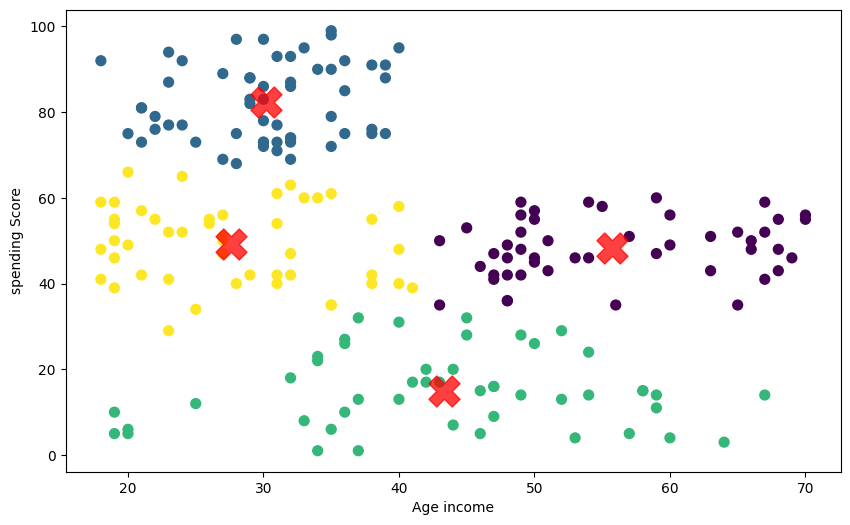

In [ ]:
plt.figure(figsize=(10,6))
plt.scatter(x.iloc[:,0],x.iloc[:,1],c=y_kmeans,s=50,cmap='viridis')
centers = kmeans.cluster_centers_
plt.scatter(centers[:,0],centers[:,1],c='red',s=500,alpha=0.75,marker="X")
plt.xlabel('Age income')
plt.ylabel('spending Score')
plt.show()

Text(0, 0.5, 'Wcss')

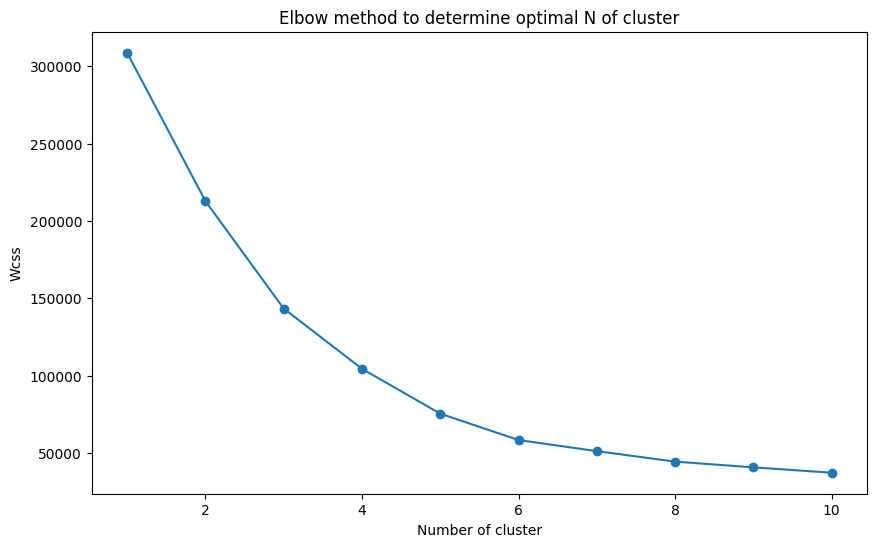

In [ ]:
x = df[['Age','AnnalIncome','SpendingScore']]
Wcss = []
for i in range(1,11):
  kmeans = KMeans(n_clusters = i,init ='k-means++',max_iter=300,n_init=10,random_state=0)
  kmeans.fit(x)
  Wcss.append(kmeans.inertia_)

plt.figure(figsize=(10,6))
plt.plot(range(1,11),Wcss,marker='o')
plt.title('Elbow method to determine optimal N of cluster')
plt.xlabel('Number of cluster')
plt.ylabel('Wcss')

In [ ]:
kmeans = KMeans(n_clusters = 6,init ='k-means++',max_iter=300,n_init=10,random_state=0)
y_kmeans = kmeans.fit_predict(x)

In [ ]:
df['ClusterAgeIncomeSpend'] = y_kmeans

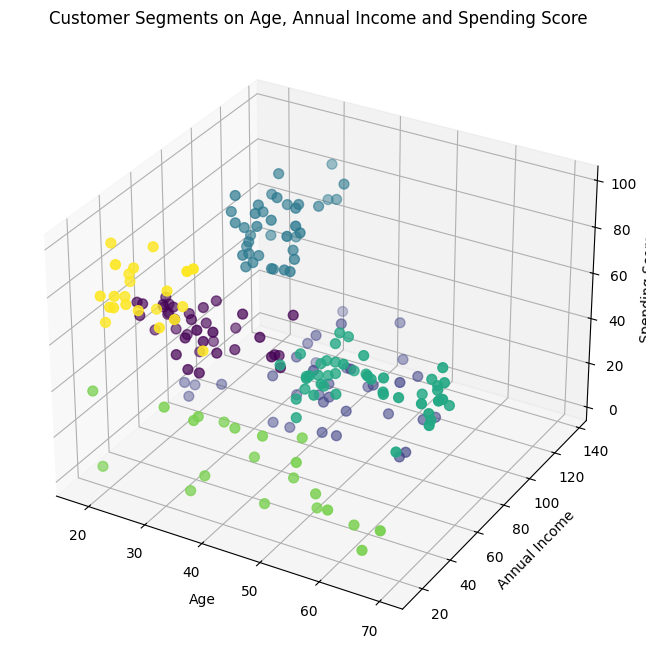

In [ ]:
from mpl_toolkits.mplot3d import Axes3D
fig = plt.figure(figsize=(10,8))
ax = fig.add_subplot(111,projection='3d')
ax.scatter(df['Age'],df['AnnalIncome'],df['SpendingScore'],c=df['ClusterAgeIncomeSpend'],s=50,cmap='viridis')
ax.set_xlabel('Age')
ax.set_ylabel('Annual Income')
ax.set_zlabel('Spending Score')
plt.title('Customer Segments on Age, Annual Income and Spending Score')
# plt.tight_layout()
plt.show()